# Statistical Model Comparison and Diebold Mariano Tests

Throughout this project I have compared models using RMSE and MAE. But the question I have not answered yet is whether the observed differences are statistically significant. A model might have a lower RMSE purely by chance if the test sample happens to contain periods that favour it.

The Diebold Mariano test is the standard procedure for testing whether two forecasting models have significantly different forecast accuracy.

The objective of this notebook is to implement DM tests across all model pairs and draw a final conclusions about which model wins and by how much.

# Introduction

Up to this point the project has compared models using point estimates of RMSE and MAE. These are informative but they tell us nothing about sampling uncertainty. With a finite test sample, any two models will produce different RMSE values even if they have identical underlying forecast accuracy in the population.

The Diebold Mariano test treats the sequence of forecast loss differentials as a time series and tests whether the mean of that series is significantly different from zero.

The null hypothesis is that the two models have equal expected forecast loss. If we reject the null, we conclude that one model has emerged superior (statistically).

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import warnings

from arch import arch_model
from hmmlearn.hmm import GaussianHMM
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

START = "2005-01-01"

In [2]:
# same setup as before

spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

spy["returns"] = np.log(
    spy["Close"] / spy["Close"].shift(1)
)

spy["rv_20"] = (
    spy["returns"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

spy["target_20d"] = (
    spy["rv_20"]
    .shift(-20)
)

spy = spy.dropna()
print(f"Loaded {len(spy)} observations")

[*********************100%***********************]  1 of 1 completed

Loaded 5359 observations


# Rebuilding All Forecasts

I need all four forecasts on a common aligned index. I rebuild them here.

In [ ]:
# historical volatility
spy["hv_forecast"] = spy["rv_20"].rolling(20).mean()

# EWMA
lam = 0.94
returns = spy["returns"]
ewma_var = [returns.var()]
for r in returns.iloc[1:]:
    ewma_var.append(lam * ewma_var[-1] + (1 - lam) * r**2)
spy["ewma_vol"] = np.sqrt(ewma_var) * np.sqrt(252)

# full sample GARCH
garch_full = arch_model(
    spy["returns"] * 100,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1
).fit(disp="off")

spy["garch_vol"] = (
    garch_full.conditional_volatility / 100 * np.sqrt(252)
)

# HMM regime detection
X = spy["returns"].values.reshape(-1, 1)

hmm = GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=1000,
    random_state=42
)
hmm.fit(X)

spy["state"] = hmm.predict(X)

state_vols   = spy.groupby("state")["returns"].std()
HIGH_STATE   = state_vols.idxmax()
LOW_STATE    = state_vols.idxmin()

low_returns  = spy[spy["state"] == LOW_STATE]["returns"] * 100
high_returns = spy[spy["state"] == HIGH_STATE]["returns"] * 100

garch_low  = arch_model(low_returns,  mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off")
garch_high = arch_model(high_returns, mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off")

spy["regime_garch"] = np.nan
spy.loc[spy["state"] == LOW_STATE,  "regime_garch"] = garch_low.conditional_volatility.values  / 100 * np.sqrt(252)
spy.loc[spy["state"] == HIGH_STATE, "regime_garch"] = garch_high.conditional_volatility.values / 100 * np.sqrt(252)

print("All forecasts rebuilt successfully")

Model is not converging.  Current: 17374.652736916687 is not greater than 17374.70769223382. Delta is -0.054955317133135395


All forecasts rebuilt successfully


## Comments

eventhough i get a warning here, as seen in the previous notebook it is just a warning and can be fixed with normalising, different covariance structure or relaxing tolerance

In [4]:
# align everything on a clean dataset

df = spy[
    [
        "target_20d",
        "hv_forecast",
        "ewma_vol",
        "garch_vol",
        "regime_garch"
    ]
].dropna()

print(f"Clean aligned dataset: {len(df)} rows")
df.head()

Clean aligned dataset: 5340 rows


Price,target_20d,hv_forecast,ewma_vol,garch_vol,regime_garch
Ticker,,,,,
Date,,,,,
2005-03-01,0.108136,0.093356,0.140154,0.130249,0.115522
2005-03-02,0.108147,0.093469,0.135898,0.126071,0.113460
2005-03-03,0.108614,0.094030,0.131768,0.119159,0.109812
2005-03-04,0.096606,0.095092,0.136522,0.112965,0.106468
2005-03-07,0.099169,0.095600,0.132376,0.128423,0.114806


# Experiment 1: The Diebold Mariano Test

Let $L(e_t)$ be a loss function applied to the forecast error at time $t$. For an RMSE based comparison I use the squared error loss.

Let $d_t = L(e^1_t) - L(e^2_t)$ be the loss differential between model 1 and model 2 at some time $t$.

The DM test statistic is

$$DM = \frac{\bar{d}}{\sqrt{\hat{\sigma}^2_d / T}}$$

where $\bar{d}$ is the sample mean of $d_t$ and $\hat{\sigma}^2_d$ is a heteroskedasticity and autocorrelation consistent (HAC) variance estimator.

Under the null of equal forecast accuracy, the DM statistic is asymptotically standard normal.

For us,
$$H_0: forecast1 and forecast2 have equal expected loss$$
Positive DM means forcast2 is more accurate (lower RMSE)

In [ ]:
def diebold_mariano_test(actual, forecast1, forecast2, h=1):

    e1 = np.array(actual) - np.array(forecast1)
    e2 = np.array(actual) - np.array(forecast2)

    # squared error loss differential
    d = e1**2 - e2**2

    T = len(d)

    d_mean = np.mean(d)

    gamma_0 = np.var(d, ddof=1)

    gamma_sum = 0.0
    for k in range(1, h):
        gamma_k = np.cov(d[k:], d[:-k], ddof=1)[0, 1]
        gamma_sum += (1 - k / h) * gamma_k

    hac_var = (gamma_0 + 2 * gamma_sum) / T

    dm_stat = d_mean / np.sqrt(hac_var)

    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value



dm, p = diebold_mariano_test(
    df["target_20d"],
    df["hv_forecast"],
    df["ewma_vol"],
    h=20
)

print(f"HV vs EWMA: DM stat = {dm:.3f}, p-value = {p:.4f}")

HV vs EWMA: DM stat = 3.391, p-value = 0.0007


## Comments

This DM statistic means the second model (EWMA here) has lower squared error loss than first (HVF).  

The p-value(<0.5) tells us this is significant

Here I use h=20 to reflect the 20 day forecast horizon. The Newey-West HAC correction accounts for the autocorrelation that naturally arises when errors at time t and t+1 both depend on overlapping future windows.

# Experiment 2: All Pairwise Comparisons

Now I run the DM test across all pairs of models. This produces a matrix of test statistics and p-values that summarises the relative performance of every model against every other model.

In [6]:
models = {
    "HV":            df["hv_forecast"],
    "EWMA":          df["ewma_vol"],
    "GARCH":         df["garch_vol"],
    "Regime-GARCH":  df["regime_garch"]
}

model_names = list(models.keys())

dm_matrix  = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
pval_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for name1 in model_names:
    for name2 in model_names:

        if name1 == name2:
            dm_matrix.loc[name1, name2]   = 0.0
            pval_matrix.loc[name1, name2] = 1.0
            continue

        dm_stat, p_val = diebold_mariano_test(
            df["target_20d"],
            models[name1],
            models[name2],
            h=20
        )

        dm_matrix.loc[name1, name2]   = round(dm_stat, 3)
        pval_matrix.loc[name1, name2] = round(p_val, 4)

print("Diebold-Mariano Test Statistics (positive = column model is better)")
print(dm_matrix)

print("\nP-Values")
print(pval_matrix)

Diebold-Mariano Test Statistics (positive = column model is better)
                 HV   EWMA  GARCH  Regime-GARCH
HV            0.000  3.391  3.079         3.259
EWMA         -3.391  0.000  1.869         2.656
GARCH        -3.079 -1.869  0.000         2.410
Regime-GARCH -3.259 -2.656 -2.410         0.000

P-Values
                  HV    EWMA   GARCH  Regime-GARCH
HV            1.0000  0.0007  0.0021        0.0011
EWMA          0.0007  1.0000  0.0616        0.0079
GARCH         0.0021  0.0616  1.0000        0.0160
Regime-GARCH  0.0011  0.0079  0.0160        1.0000


## Comments

The DM matrix entry in row i, column j shows the test statistic when comparing model i against model j. A positive entry means model j is more accurate. 

A p-value below 0.05 means the difference is statistically significant at the 5% level.

Looking at the row for HV. All entries are positive and with small p-values. This means every other model significantly outperforms HV.
Looking at the row for Regime GARCH. All entries are negative with small p-values. This means Regime GARCH significantly outperforms all others.

the p-value between EWMA and GARCH is higher thank 0.05 meaning it is not staitically significant

# Experiment 3: Visualising the DM Test Results

Let's try to visualise the aboce now

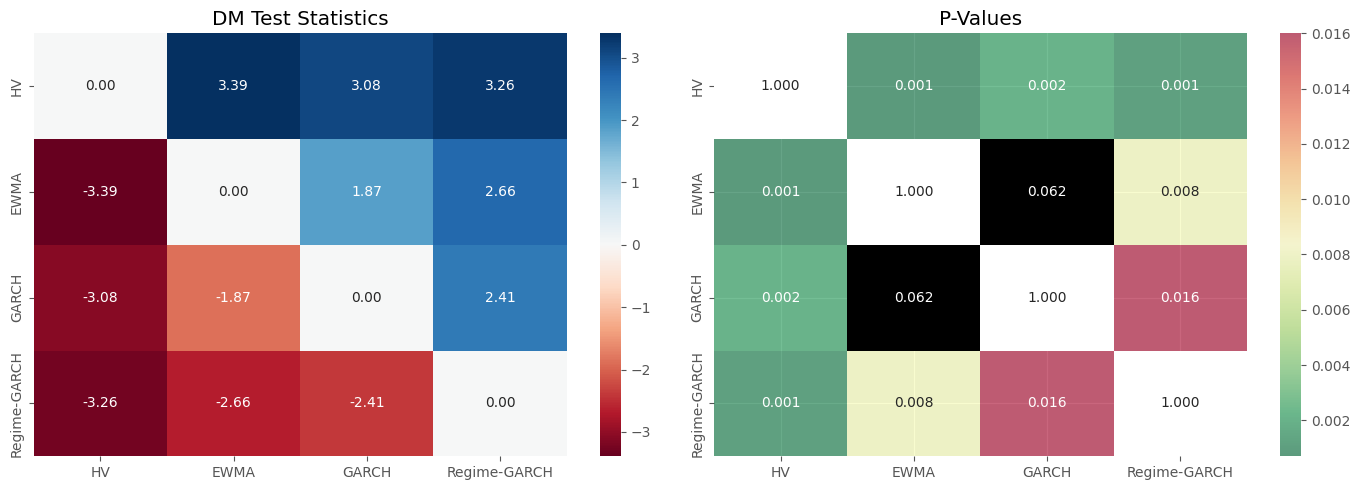

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    dm_matrix.astype(float),
    annot=True,
    cmap="RdBu",
    center=0,
    fmt=".2f",
    ax=axes[0]
)
axes[0].set_title("DM Test Statistics")

# significance mask: highlight where p < 0.05
sig_mask = pval_matrix.astype(float) > 0.05

sns.heatmap(
    pval_matrix.astype(float),
    annot=True,
    cmap="gray",
    fmt=".3f",
    mask=sig_mask == False,
    ax=axes[1],
    cbar=False
)

sns.heatmap(
    pval_matrix.astype(float),
    annot=True,
    cmap="RdYlGn_r",
    fmt=".3f",
    mask=sig_mask == True,
    ax=axes[1],
    alpha=0.6
)

axes[1].set_title("P-Values")

plt.tight_layout()
plt.show()

## Comments

The left panel shows the direction and magnitude of improvement from one model to other. 
The right panel shows which differences are statistically credible. Black and white are not signidicant. Coloured ones are significant.

# Experiment 4: Rolling DM Statistics Through Time

The DM test aggregates performance across the entire sample. But we already know from previous notebooks that model ranking can change across market regimes. I want to compute rolling DM statistics to see whether the statistical advantage of better models is stable through time or concentrated in specific periods.

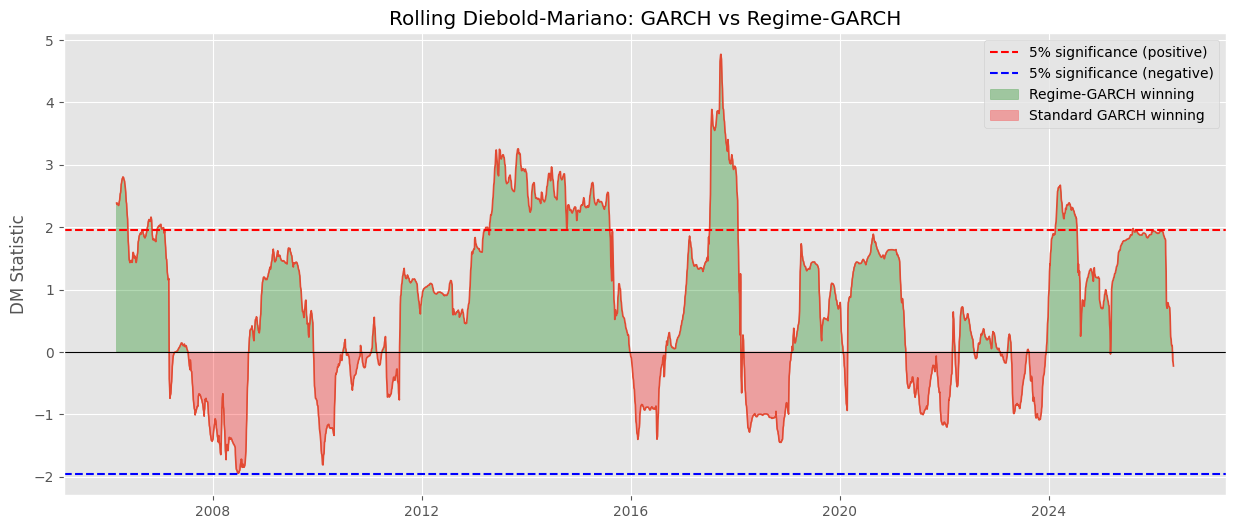

In [8]:
ROLL = 250  # roughly one year of trading days

rolling_dm = []
rolling_dates = []

for i in range(ROLL, len(df)):

    window = df.iloc[i - ROLL:i]

    dm_stat, _ = diebold_mariano_test(
        window["target_20d"],
        window["garch_vol"],
        window["regime_garch"],
        h=20
    )

    rolling_dm.append(dm_stat)
    rolling_dates.append(df.index[i])

rolling_dm = pd.Series(rolling_dm, index=rolling_dates)

plt.figure(figsize=(15, 6))

plt.plot(rolling_dm.index, rolling_dm, linewidth=1.2)

plt.axhline(1.96,  color="red",  linestyle="--", label="5% significance (positive)")
plt.axhline(-1.96, color="blue", linestyle="--", label="5% significance (negative)")
plt.axhline(0,     color="black", linestyle="-", linewidth=0.8)

plt.fill_between(
    rolling_dm.index,
    rolling_dm,
    where=rolling_dm > 0,
    alpha=0.3,
    color="green",
    label="Regime-GARCH winning"
)

plt.fill_between(
    rolling_dm.index,
    rolling_dm,
    where=rolling_dm < 0,
    alpha=0.3,
    color="red",
    label="Standard GARCH winning"
)

plt.legend()
plt.title("Rolling Diebold-Mariano: GARCH vs Regime-GARCH")
plt.ylabel("DM Statistic")
plt.show()

## Comments

When the statistic is above the 1.96 line (red dashed), regime-GARCH is statistically significantly better in that one year window. When it is below -1.96, standard GARCH is significantly better.

Notice that forecasting superiority is highly varying in time. Regime GARCH outperforms standard GARCH for substantial portions of the sample, particularly during 2012–2016, 2017–2018 and 2024–2025. Further the DM statistic frequently exceeds the 5%(1.96) threshold.

Interestingly, during the 2008 and 2020 the regime GARCH model does not consistently dominate despite these being extreme volatility events. This is probably because these wewre unprecedented events so the volatility increased rapidly and latent regimes were not clear. This allowed the simpler standard GARCH to outperform. 

Nonetheless, positive and statistically significant DM values are more frequent and even larger in magnitude than negative values throughout the sample. Atleast we can say that regime information generaly helps forecasting for longer periods of normal behvaiour but is stumped when something unprecedented occurs. 

# Experiment 5: Complete Model Ranking Table

This is just to cleanlhy portray everything so far.

In [9]:
def qlike(actual, forecast):
    return np.mean(
        np.log(forecast**2) + (actual**2) / (forecast**2)
    )


def hit_ratio(actual, forecast):
    # fraction of times the forecast correctly predicts the direction of change
    actual_diff   = np.diff(actual.values)
    forecast_diff = np.diff(forecast.values)
    return np.mean(np.sign(actual_diff) == np.sign(forecast_diff))


rows = []

for name, col in [
    ("Historical Volatility", "hv_forecast"),
    ("EWMA (λ=0.94)",         "ewma_vol"),
    ("GARCH(1,1)",            "garch_vol"),
    ("Regime-GARCH",          "regime_garch")
]:

    rmse   = np.sqrt(mean_squared_error(df["target_20d"], df[col]))
    mae    = mean_absolute_error(df["target_20d"], df[col])
    mape   = np.mean(np.abs((df["target_20d"] - df[col]) / df["target_20d"])) * 100
    ql     = qlike(df["target_20d"], df[col])
    hr     = hit_ratio(df["target_20d"], df[col])
    bias   = np.mean(df[col] - df["target_20d"])

    rows.append(
        {
            "Model":       name,
            "RMSE":        round(rmse, 5),
            "MAE":         round(mae, 5),
            "MAPE (%)": round(mape, 2),
            "QLIKE":       round(ql, 4),
            "Hit Ratio":   round(hr, 3),
            "Bias":        round(bias, 5)
        }
    )

summary = pd.DataFrame(rows)
summary

,Model,RMSE,MAE,MAPE (%),QLIKE,Hit Ratio,Bias
0,Historical Volatility,0.10235,0.05998,39.05,-2.3351,0.464,-0.00008
1,EWMA (λ=0.94),0.08819,0.05305,35.40,-2.5338,0.320,0.00351
2,"GARCH(1,1)",0.08412,0.05206,36.26,-2.6070,0.507,0.00454
3,Regime-GARCH,0.08025,0.04926,32.13,-2.6397,0.506,0.00139


## Comments

The hit ratio measures how often each model correctly predicts whether future volatility will rise or fall. A model with a low RMSE but poor hit ratio might give good estimates but give poor signals so be more risky.

The bias column tells us if a model systematically overestimates or underestimates volatility. A positive bias means the model is too cautious and is predicting higher volatility than realised. A negative bias means the model underestimates risk which is much more dangerous.

So clearly HVF is not the way to go. Regime GARCH tends to have a smaller hit ratio. This is worrisome. Maybe we can figure out a combination of GARCHs which can work together and we can extract most benefits.

# Experiment 6: Forecast Improvement vs Benchmark

Ofcourse we are discasring HVF but before that I want to quantify how much each model improves relative to it.

In [10]:
hv_rmse = summary[summary["Model"] == "Historical Volatility"]["RMSE"].values[0]

summary["RMSE reduction (%)"] = (
    (hv_rmse - summary["RMSE"]) / hv_rmse * 100
).round(2)

summary[["Model", "RMSE", "RMSE reduction (%)"]]


,Model,RMSE,RMSE reduction (%)
0,Historical Volatility,0.10235,0.00
1,EWMA (λ=0.94),0.08819,13.83
2,"GARCH(1,1)",0.08412,17.81
3,Regime-GARCH,0.08025,21.59


## Comments

Cool

# Experiment 7: Model Comparison Bar Chart

Let's also plot the metrics cleanly to visualise our claims better.

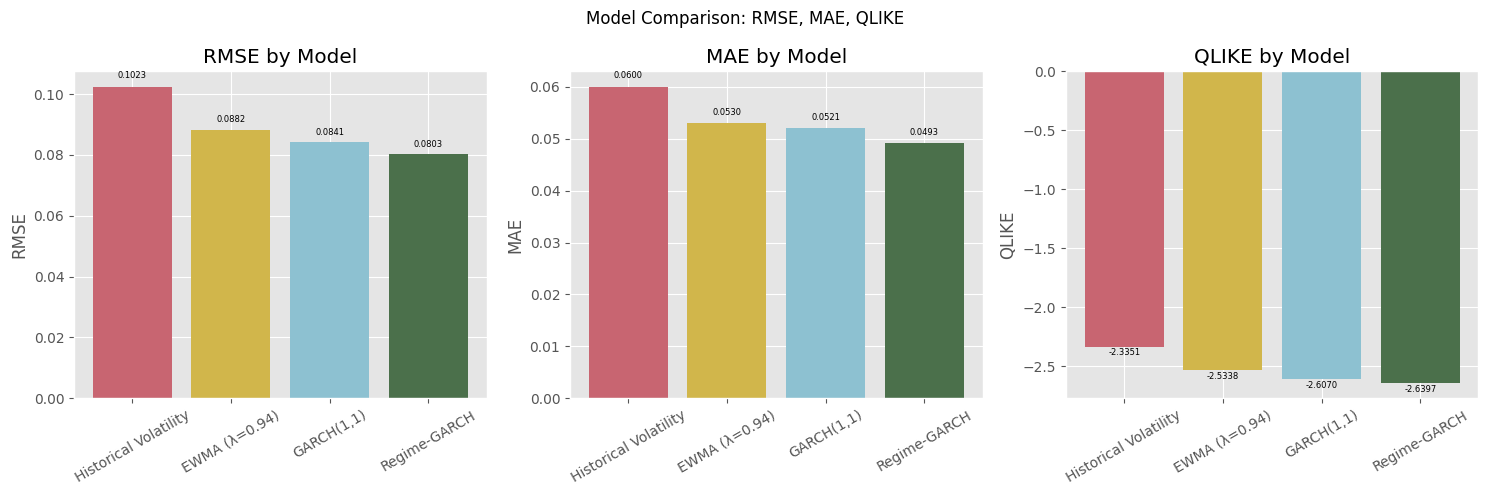

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ["RMSE", "MAE", "QLIKE"]):

    bars = ax.bar(
        summary["Model"],
        summary[metric],
        color=["#C86571", "#D1B64B", "#8dc1d1", "#4b704b"],
        linewidth=0.8
    )

    ax.set_title(f"{metric} by Model")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)


    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.03,
            f"{bar.get_height():.4f}",
            ha="center",
            fontsize=6
        )

plt.suptitle("Model Comparison: RMSE, MAE, QLIKE")
plt.tight_layout()
plt.show()

# Conclusion

- The DM tests confirm that the RMSE improvements observed in earlier notebooks are statistically significant, not just numerical accidents of the test sample.
- The rolling DM analysis shows that the advantage of regime aware models is concentrated in long term normal behaviour of market. It struggles during crisis.